In [1]:
import sys, os
from utils import * 


In [2]:
import joblib

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("IEEE_data.pkl")
y_test = y_test.values.ravel()

MODEL_NAME = "BGMM_Gibbs"
DE_LONG_RESULTS = "IEEE_CIS_all_results.pkl"
METRICS = "IEEE_CIS_metrics.pkl"


In [3]:
# ==================================================================
# ==================================================================
# ==================================================================
# ==================================================================
# ==================================================================
# ===================== 1. Fit BGMM with GIBBS =====================
# ==================================================================
# ==================================================================
# ==================================================================
# ==================================================================
# ==================================================================

In [4]:
# ===================== Fit BGMM with GIBBS =====================
bgmm_gibbs_train_scores, bgmm_gibbs_test_scores, bgmm = run_bgmm_gibbs(X_train, X_test)

In [5]:
# ===================== Store metrics =====================
bgmm_metrics = store_anomaly_metrics(y_true=y_test, scores=bgmm_gibbs_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)
display(bgmm_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,BGMM_Gibbs,train_transaction22,0.095665,0.088-0.103,0.136705,0.126-0.148,0.112561,0.104-0.121,0.542193,0.533-0.551,0.048932,0.046-0.052,"[[108634, 5341], [3568, 565]]",3.680655e+11


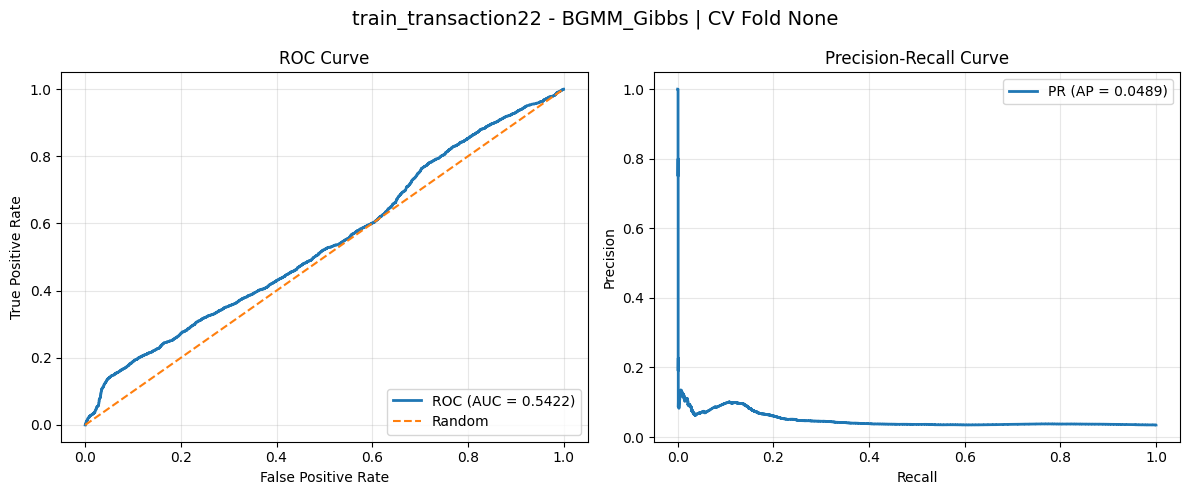

In [6]:
# ===================== Plot results =====================

plot_anomaly_roc_pr(y_true=y_test, dataset_name=DATASET_NAME, scores=bgmm_gibbs_test_scores, model_name=MODEL_NAME)


In [7]:
# ===================== Fit on CV folds =====================

bgmm_cv_results = fit_cross_validate(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, model_func=run_bgmm_gibbs, dataset_name=DATASET_NAME, model_name=MODEL_NAME, cv=CV_FOLDS, random_state=RANDOM_STATE)


In [8]:
# ===================== Store CV metrics =====================
bgmm_cv_metrics = pd.concat([r["test_metrics"] for r in bgmm_cv_results], ignore_index=True)
display(bgmm_cv_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,BGMM_Gibbs_Fold1,train_transaction22,0.093803,0.087-0.101,0.134043,0.124-0.145,0.110370,0.102-0.119,0.541911,0.533-0.551,0.048834,0.046-0.052,"[[108623, 5352], [3579, 554]]",2.356655e+11
1,BGMM_Gibbs_Fold2,train_transaction22,0.094707,0.087-0.102,0.135495,0.125-0.146,0.111487,0.103-0.120,0.541857,0.533-0.551,0.048852,0.046-0.052,"[[108622, 5353], [3573, 560]]",2.357221e+11
2,BGMM_Gibbs_Fold3,train_transaction22,0.095246,0.088-0.103,0.136221,0.126-0.147,0.112107,0.104-0.121,0.542432,0.534-0.552,0.049000,0.046-0.052,"[[108627, 5348], [3570, 563]]",2.354297e+11
3,BGMM_Gibbs_Fold4,train_transaction22,0.095835,0.088-0.104,0.136947,0.127-0.148,0.112760,0.104-0.122,0.542502,0.534-0.552,0.049069,0.046-0.053,"[[108635, 5340], [3567, 566]]",2.356797e+11
4,BGMM_Gibbs_Fold5,train_transaction22,0.095157,0.088-0.103,0.135979,0.126-0.147,0.111963,0.104-0.121,0.542221,0.533-0.551,0.048901,0.046-0.052,"[[108631, 5344], [3571, 562]]",2.353153e+11


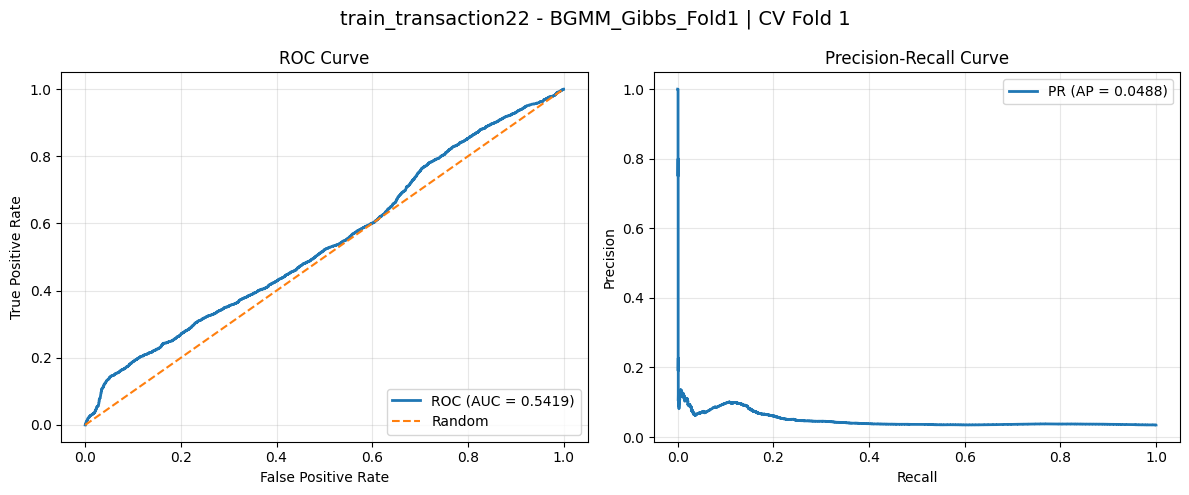

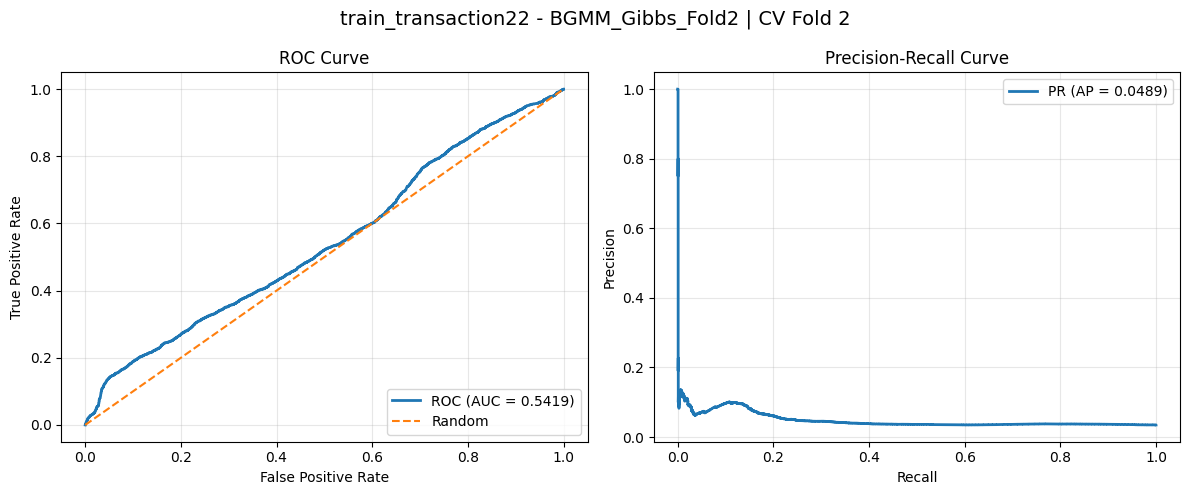

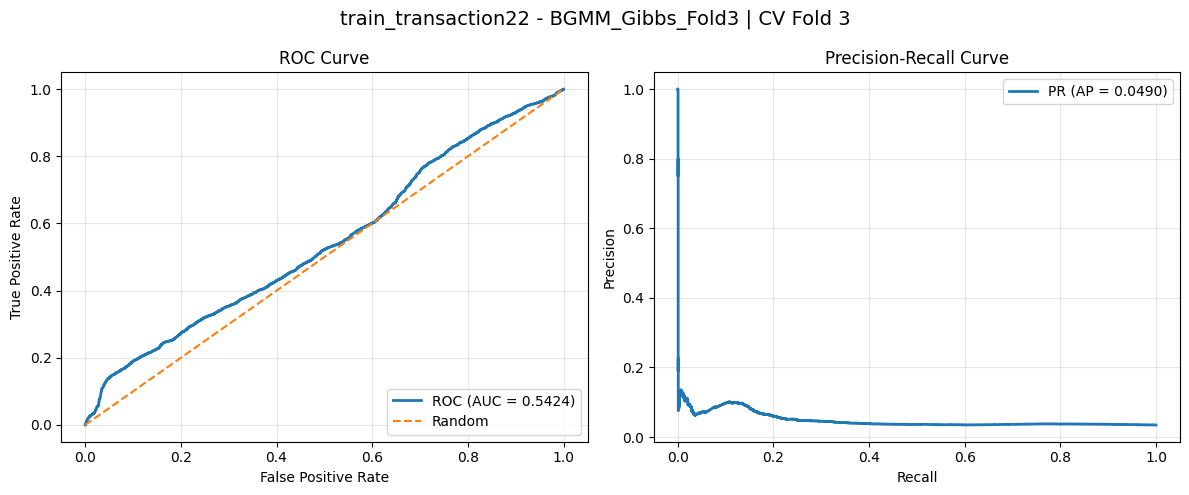

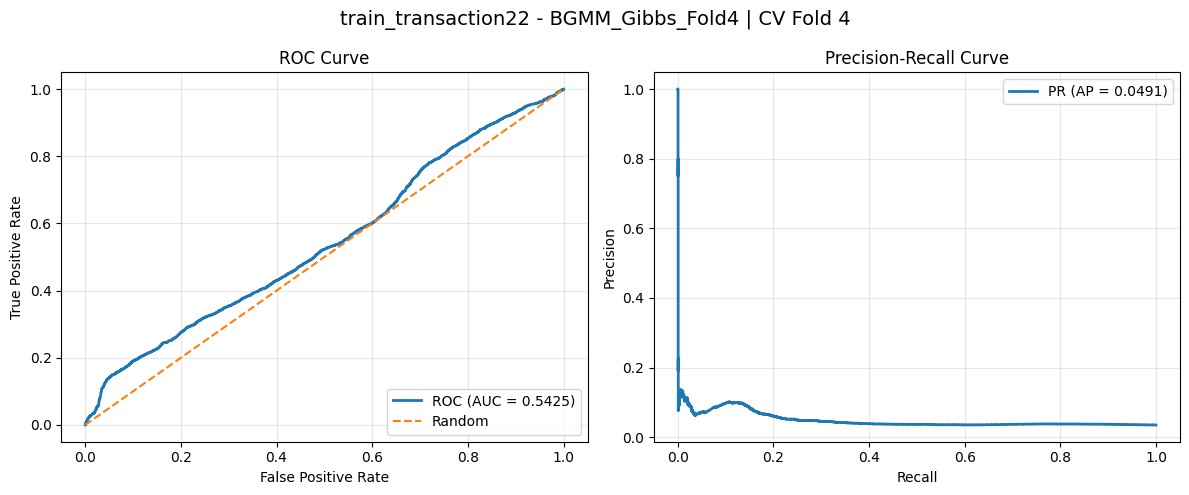

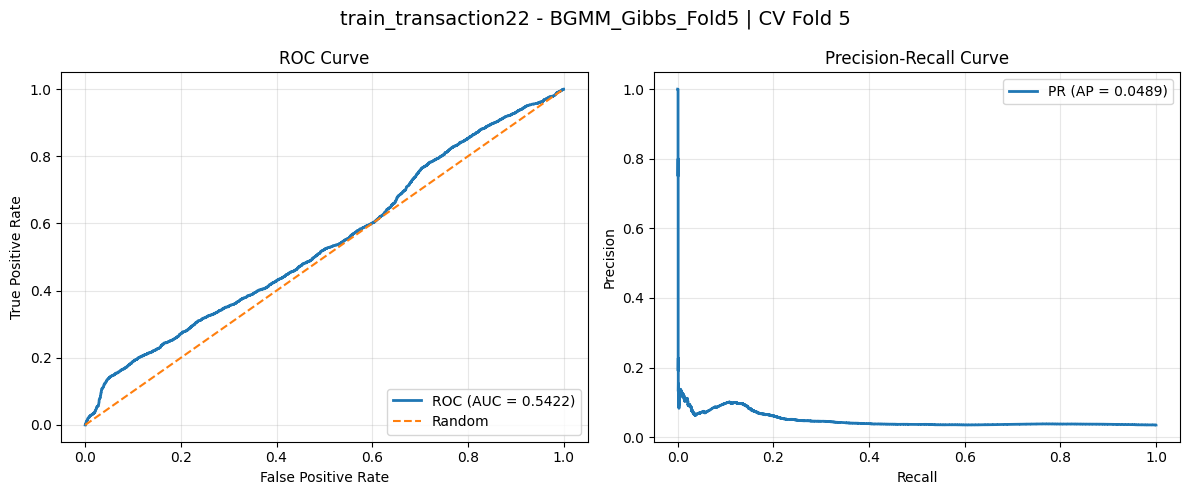

In [9]:
# ===================== Plot CV results =====================

for r in bgmm_cv_results:
    plot_anomaly_roc_pr(y_test, r["test_scores"], DATASET_NAME, f"{MODEL_NAME}_Fold{r['fold']}", r["fold"])


In [15]:
if os.path.exists(DE_LONG_RESULTS):
    results = joblib.load(DE_LONG_RESULTS)
else:
    results = {}

results[MODEL_NAME] = {
    "test_scores": bgmm_gibbs_test_scores,
    "auc": roc_auc_score(y_test, bgmm_gibbs_test_scores)
}

joblib.dump(results, DE_LONG_RESULTS)

['IEEE_CIS_all_results.pkl']

In [14]:
if os.path.exists(METRICS):
    results = joblib.load(METRICS)
else:
    results = {}

results[MODEL_NAME] = {
    "metrics": bgmm_metrics,
    "cv_metrics": bgmm_cv_metrics
}

joblib.dump(results, METRICS)

['IEEE_CIS_metrics.pkl']